**Downloading the datasets**

In [1]:
!pip install medmnist
from medmnist import PneumoniaMNIST, BloodMNIST

pneumonia_train = PneumoniaMNIST(split="train", download=True)
pneumonia_test  = PneumoniaMNIST(split="test",  download=True)
blood_train     = BloodMNIST(split="train",     download=True)
blood_test      = BloodMNIST(split="test",      download=True)

print(pneumonia_train)
print(blood_train)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.1 MB/s eta 0:00:00


100%|██████████| 4.17M/4.17M [00:02<00:00, 1.64MB/s]
100%|██████████| 35.5M/35.5M [00:55<00:00, 637kB/s]


Dataset PneumoniaMNIST of size 28 (pneumoniamnist)
    Number of datapoints: 4708
    Root location: /root/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'normal', '1': 'pneumonia'}
    Number of samples: {'train': 4708, 'val': 524, 'test': 624}
    Description: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
    License: CC BY 4.0
Dataset BloodMNIST of size 28 (bloodmnist)
    Number of datapoints: 11959
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinop

imports and seeds

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
torch.manual_seed(42)

pneu_classes = ['normal', 'pneumonia']
blood_classes = ['basophil','eosinophil','erythroblast','immature gran.',
                 'lymphocyte','monocyte','neutrophil','platelet']

In [3]:
P_imgs, P_lbls = pneumonia_train.imgs, pneumonia_train.labels.flatten()
B_imgs, B_lbls = blood_train.imgs, blood_train.labels.flatten()
print("Pneumonia images:", P_imgs.shape, "| Blood images:", B_imgs.shape)

Pneumonia images: (4708, 28, 28) | Blood images: (11959, 28, 28, 3)


**EDA**

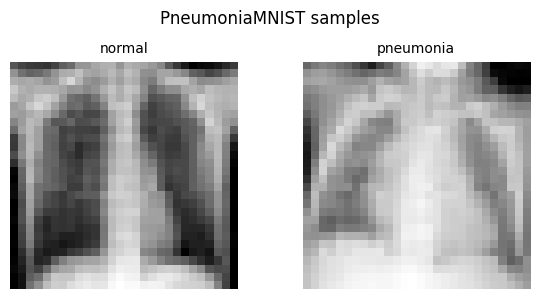

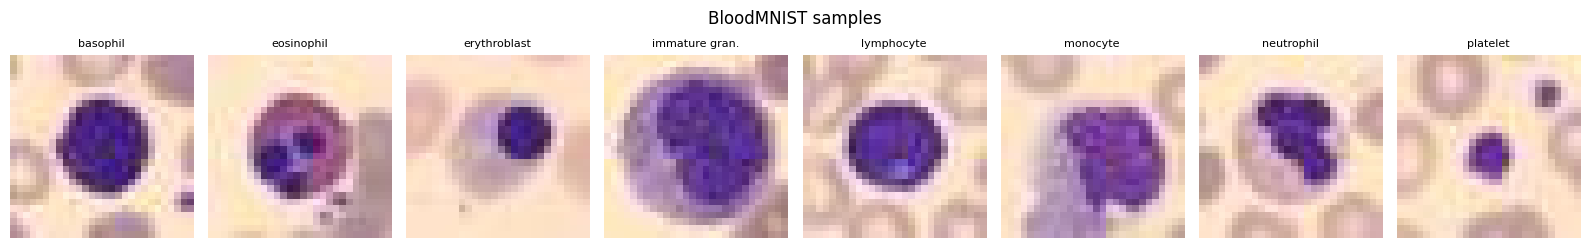

In [4]:
#look at sample images
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for i in range(2):
    idx = np.where(P_lbls == i)[0][0]
    axes[i].imshow(P_imgs[idx], cmap='gray')
    axes[i].set_title(pneu_classes[i], fontsize=10)
    axes[i].axis('off')
plt.suptitle('PneumoniaMNIST samples')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for i in range(8):
    idx = np.where(B_lbls == i)[0][0]
    axes[i].imshow(B_imgs[idx])
    axes[i].set_title(blood_classes[i], fontsize=8)
    axes[i].axis('off')
plt.suptitle('BloodMNIST samples')
plt.tight_layout(); plt.show()

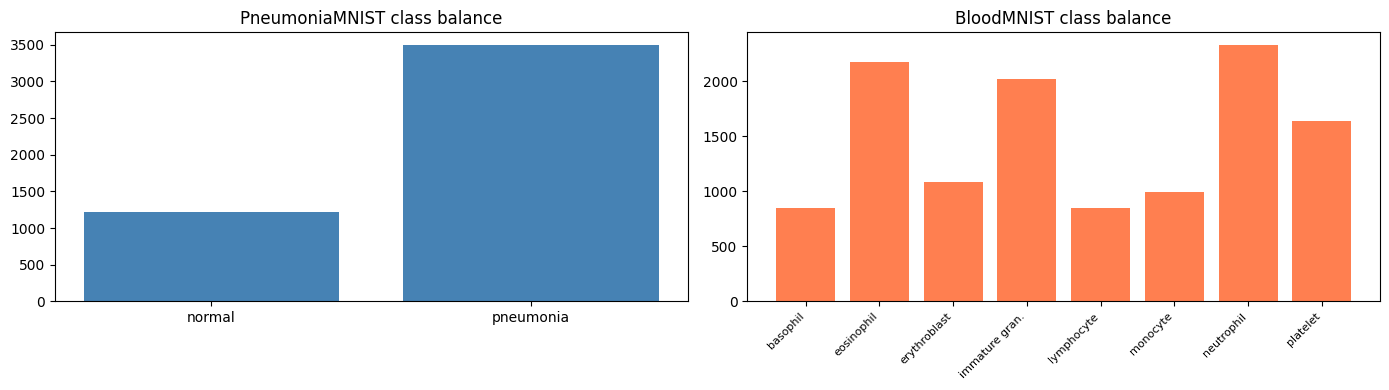

Pneumonia counts: {'normal': np.int64(1214), 'pneumonia': np.int64(3494)}
Blood counts: [ 852 2181 1085 2026  849  993 2330 1643]


In [5]:
#class balance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(pneu_classes, np.bincount(P_lbls), color='steelblue')
ax1.set_title('PneumoniaMNIST class balance')

ax2.bar(range(8), np.bincount(B_lbls), color='coral')
ax2.set_xticks(range(8)); ax2.set_xticklabels(blood_classes, rotation=45, ha='right', fontsize=8)
ax2.set_title('BloodMNIST class balance')

plt.tight_layout(); plt.show()

print("Pneumonia counts:", dict(zip(pneu_classes, np.bincount(P_lbls))))
print("Blood counts:", np.bincount(B_lbls))

In [6]:
#feature summary
print("=== Input Feature Summary ===")
print(f"Pneumonia: {P_imgs.shape} | grayscale | MLP input = {28*28}")
print(f"  pixel mean {P_imgs.mean():.1f}, std {P_imgs.std():.1f}")
print(f"Blood: {B_imgs.shape} | RGB | MLP input = {28*28*3}")
print(f"  pixel mean {B_imgs.mean():.1f}, std {B_imgs.std():.1f}")
print("\nMissing values: none (MedMNIST is pre-cleaned)")

=== Input Feature Summary ===
Pneumonia: (4708, 28, 28) | grayscale | MLP input = 784
  pixel mean 145.8, std 42.9
Blood: (11959, 28, 28, 3) | RGB | MLP input = 2352
  pixel mean 182.8, std 52.8

Missing values: none (MedMNIST is pre-cleaned)


**ML**

In [7]:
#Random forest
# Flatten images into vectors and scale to 0-1
Xp_tr = P_imgs.reshape(len(P_imgs), -1) / 255.0
Xp_te = pneumonia_test.imgs.reshape(len(pneumonia_test.imgs), -1) / 255.0
yp_tr, yp_te = P_lbls, pneumonia_test.labels.flatten()

Xb_tr = B_imgs.reshape(len(B_imgs), -1) / 255.0
Xb_te = blood_test.imgs.reshape(len(blood_test.imgs), -1) / 255.0
yb_tr, yb_te = B_lbls, blood_test.labels.flatten()

# Random Forest on Pneumonia
print("Training Random Forest on Pneumonia...")
rf_p = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_p.fit(Xp_tr, yp_tr)
rf_p_acc = accuracy_score(yp_te, rf_p.predict(Xp_te))
rf_p_f1 = f1_score(yp_te, rf_p.predict(Xp_te), average='macro')
print(f"  Accuracy {rf_p_acc:.4f} | Macro F1 {rf_p_f1:.4f}")

# Random Forest on Blood
print("Training Random Forest on Blood...")
rf_b = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_b.fit(Xb_tr, yb_tr)
rf_b_acc = accuracy_score(yb_te, rf_b.predict(Xb_te))
rf_b_f1 = f1_score(yb_te, rf_b.predict(Xb_te), average='macro')
print(f"  Accuracy {rf_b_acc:.4f} | Macro F1 {rf_b_f1:.4f}")

Training Random Forest on Pneumonia...
  Accuracy 0.8526 | Macro F1 0.8294
Training Random Forest on Blood...
  Accuracy 0.8372 | Macro F1 0.8084


In [8]:
from sklearn.svm import LinearSVC

# Linear SVM on Pneumonia
print("Training Linear SVM on Pneumonia...")
svm_p = LinearSVC(random_state=42, max_iter=2000)
svm_p.fit(Xp_tr, yp_tr)
svm_p_acc = accuracy_score(yp_te, svm_p.predict(Xp_te))
svm_p_f1 = f1_score(yp_te, svm_p.predict(Xp_te), average='macro')
print(f"  Accuracy {svm_p_acc:.4f} | Macro F1 {svm_p_f1:.4f}")

# Linear SVM on Blood
print("Training Linear SVM on Blood...")
svm_b = LinearSVC(random_state=42, max_iter=2000)
svm_b.fit(Xb_tr, yb_tr)
svm_b_acc = accuracy_score(yb_te, svm_b.predict(Xb_te))
svm_b_f1 = f1_score(yb_te, svm_b.predict(Xb_te), average='macro')
print(f"  Accuracy {svm_b_acc:.4f} | Macro F1 {svm_b_f1:.4f}")

Training Linear SVM on Pneumonia...
  Accuracy 0.8253 | Macro F1 0.7910
Training Linear SVM on Blood...
  Accuracy 0.7977 | Macro F1 0.7777


In [17]:
from sklearn.svm import SVC

# RBF SVM on Pneumonia
print("Training RBF SVM on Pneumonia...")
svm_p = SVC(kernel='rbf', random_state=42)
svm_p.fit(Xp_tr, yp_tr)
svm_p_acc = accuracy_score(yp_te, svm_p.predict(Xp_te))
svm_p_f1 = f1_score(yp_te, svm_p.predict(Xp_te), average='macro')
print(f"  Accuracy {svm_p_acc:.4f} | Macro F1 {svm_p_f1:.4f}")

# RBF SVM on Blood
print("Training RBF SVM on Blood...")
svm_b = SVC(kernel='rbf', random_state=42)
svm_b.fit(Xb_tr, yb_tr)
svm_b_acc = accuracy_score(yb_te, svm_b.predict(Xb_te))
svm_b_f1 = f1_score(yb_te, svm_b.predict(Xb_te), average='macro')
print(f"  Accuracy {svm_b_acc:.4f} | Macro F1 {svm_b_f1:.4f}")

Training RBF SVM on Pneumonia...
  Accuracy 0.8542 | Macro F1 0.8291
Training RBF SVM on Blood...
  Accuracy 0.8471 | Macro F1 0.8229


**MLP**

In [9]:
# Load validation splits (for tuning without touching test)
pneumonia_val = PneumoniaMNIST(split="val", download=True)
blood_val     = BloodMNIST(split="val", download=True)

# Pneumonia arrays
Xp_val = pneumonia_val.imgs.reshape(len(pneumonia_val.imgs), -1) / 255.0
yp_val = pneumonia_val.labels.flatten()

# Blood arrays
Xb_val = blood_val.imgs.reshape(len(blood_val.imgs), -1) / 255.0
yb_val = blood_val.labels.flatten()

# Standardise: subtract mean, divide by std (computed from TRAIN only)
def standardise(X_tr, *others):
    mean, std = X_tr.mean(0), X_tr.std(0) + 1e-8
    return [(X - mean) / std for X in (X_tr, *others)]

Xp_tr_s, Xp_val_s, Xp_te_s = standardise(Xp_tr, Xp_val, Xp_te)
Xb_tr_s, Xb_val_s, Xb_te_s = standardise(Xb_tr, Xb_val, Xb_te)

print("Standardised. Pneumonia train:", Xp_tr_s.shape, "| Blood train:", Xb_tr_s.shape)

Standardised. Pneumonia train: (4708, 784) | Blood train: (11959, 2352)


In [10]:
import copy

def train_good_mlp(X_tr, y_tr, X_val, y_val, input_size, num_classes,
                   h1=512, h2=256, dropout=0.3, lr=1e-3, batch_size=128,
                   max_epochs=100, patience=10):
    torch.manual_seed(42)
    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr)),
        batch_size=batch_size, shuffle=True)

    model = nn.Sequential(
        nn.Linear(input_size, h1), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(h2, num_classes))
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    Xv = torch.FloatTensor(X_val)
    best_acc, best_state, wait, history = 0, None, 0, []

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(Xv).argmax(1).numpy()
        val_acc = accuracy_score(y_val, val_preds)
        history.append(val_acc)

        if val_acc > best_acc:
            best_acc, best_state, wait = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  early stop at epoch {epoch+1}")
                break

        if (epoch+1) % 5 == 0:
            print(f"  epoch {epoch+1}: val acc {val_acc:.4f} (best {best_acc:.4f})")

    model.load_state_dict(best_state)
    return model, history, best_acc

In [11]:
print("Training MLP on Pneumonia...")
mlp_p, hist_p, best_p = train_good_mlp(Xp_tr_s, yp_tr, Xp_val_s, yp_val,
                                       input_size=784, num_classes=2)

# Final test-set evaluation
mlp_p.eval()
with torch.no_grad():
    preds = mlp_p(torch.FloatTensor(Xp_te_s)).argmax(1).numpy()
mlp_p_acc = accuracy_score(yp_te, preds)
mlp_p_f1 = f1_score(yp_te, preds, average='macro')
print(f"\nPneumonia MLP — Test Accuracy {mlp_p_acc:.4f} | Macro F1 {mlp_p_f1:.4f}")

Training MLP on Pneumonia...
  epoch 5: val acc 0.9580 (best 0.9695)
  epoch 10: val acc 0.9542 (best 0.9695)
  early stop at epoch 14

Pneumonia MLP — Test Accuracy 0.8333 | Macro F1 0.8009


In [12]:
print("Retuning MLP on Pneumonia (gentler)...")
mlp_p, hist_p, best_p = train_good_mlp(
    Xp_tr_s, yp_tr, Xp_val_s, yp_val,
    input_size=784, num_classes=2,
    h1=512, h2=256,
    dropout=0.5,        # more dropout
    lr=3e-4,            # gentler learning rate
    batch_size=128,
    max_epochs=150,
    patience=25)        # more patience

mlp_p.eval()
with torch.no_grad():
    preds = mlp_p(torch.FloatTensor(Xp_te_s)).argmax(1).numpy()
mlp_p_acc = accuracy_score(yp_te, preds)
mlp_p_f1 = f1_score(yp_te, preds, average='macro')
print(f"\nPneumonia MLP — Test Accuracy {mlp_p_acc:.4f} | Macro F1 {mlp_p_f1:.4f}")

Retuning MLP on Pneumonia (gentler)...
  epoch 5: val acc 0.9561 (best 0.9637)
  epoch 10: val acc 0.9542 (best 0.9637)
  epoch 15: val acc 0.9599 (best 0.9637)
  epoch 20: val acc 0.9676 (best 0.9676)
  epoch 25: val acc 0.9637 (best 0.9676)
  epoch 30: val acc 0.9676 (best 0.9676)
  epoch 35: val acc 0.9656 (best 0.9676)
  epoch 40: val acc 0.9637 (best 0.9676)
  early stop at epoch 45

Pneumonia MLP — Test Accuracy 0.8510 | Macro F1 0.8253


In [13]:
print("Training MLP on Blood...")
mlp_b, hist_b, best_b = train_good_mlp(
    Xb_tr_s, yb_tr, Xb_val_s, yb_val,
    input_size=2352, num_classes=8,
    h1=512, h2=256,
    dropout=0.3,
    lr=1e-3,
    batch_size=128,
    max_epochs=150,
    patience=20)

mlp_b.eval()
with torch.no_grad():
    preds = mlp_b(torch.FloatTensor(Xb_te_s)).argmax(1).numpy()
mlp_b_acc = accuracy_score(yb_te, preds)
mlp_b_f1 = f1_score(yb_te, preds, average='macro')
print(f"\nBlood MLP — Test Accuracy {mlp_b_acc:.4f} | Macro F1 {mlp_b_f1:.4f}")

Training MLP on Blood...
  epoch 5: val acc 0.8464 (best 0.8598)
  epoch 10: val acc 0.8633 (best 0.8662)
  epoch 15: val acc 0.8721 (best 0.8750)
  epoch 20: val acc 0.8680 (best 0.8750)
  epoch 25: val acc 0.8703 (best 0.8750)
  epoch 30: val acc 0.8680 (best 0.8803)
  epoch 35: val acc 0.8668 (best 0.8803)
  epoch 40: val acc 0.8686 (best 0.8803)
  epoch 45: val acc 0.8709 (best 0.8803)
  epoch 50: val acc 0.8715 (best 0.8808)
  epoch 55: val acc 0.8657 (best 0.8808)
  epoch 60: val acc 0.8756 (best 0.8832)
  epoch 65: val acc 0.8750 (best 0.8832)
  epoch 70: val acc 0.8803 (best 0.8832)
  epoch 75: val acc 0.8826 (best 0.8832)
  early stop at epoch 77

Blood MLP — Test Accuracy 0.8623 | Macro F1 0.8461


In [14]:
print("Training MLP on Blood (wider: h1=1024)...")
mlp_b, hist_b, best_b = train_good_mlp(
    Xb_tr_s, yb_tr, Xb_val_s, yb_val,
    input_size=2352, num_classes=8,
    h1=1024, h2=256,    # wider first layer
    dropout=0.3,
    lr=1e-3,
    batch_size=128,
    max_epochs=150,
    patience=20)

mlp_b.eval()
with torch.no_grad():
    preds = mlp_b(torch.FloatTensor(Xb_te_s)).argmax(1).numpy()
mlp_b_acc = accuracy_score(yb_te, preds)
mlp_b_f1 = f1_score(yb_te, preds, average='macro')
print(f"\nBlood MLP (wide) — Test Accuracy {mlp_b_acc:.4f} | Macro F1 {mlp_b_f1:.4f}")

Training MLP on Blood (wider: h1=1024)...
  epoch 5: val acc 0.8581 (best 0.8633)
  epoch 10: val acc 0.8709 (best 0.8709)
  epoch 15: val acc 0.8797 (best 0.8803)
  epoch 20: val acc 0.8709 (best 0.8803)
  epoch 25: val acc 0.8692 (best 0.8803)
  epoch 30: val acc 0.8820 (best 0.8820)
  epoch 35: val acc 0.8727 (best 0.8820)
  epoch 40: val acc 0.8657 (best 0.8820)
  epoch 45: val acc 0.8586 (best 0.8820)
  early stop at epoch 50

Blood MLP (wide) — Test Accuracy 0.8571 | Macro F1 0.8358


In [15]:
print("Retraining best Blood MLP (h1=512)...")
mlp_b, hist_b, best_b = train_good_mlp(
    Xb_tr_s, yb_tr, Xb_val_s, yb_val,
    input_size=2352, num_classes=8,
    h1=512, h2=256, dropout=0.3, lr=1e-3,
    batch_size=128, max_epochs=150, patience=20)

mlp_b.eval()
with torch.no_grad():
    preds = mlp_b(torch.FloatTensor(Xb_te_s)).argmax(1).numpy()
mlp_b_acc = accuracy_score(yb_te, preds)
mlp_b_f1 = f1_score(yb_te, preds, average='macro')
print(f"\nBlood MLP (final) — Test Accuracy {mlp_b_acc:.4f} | Macro F1 {mlp_b_f1:.4f}")

Retraining best Blood MLP (h1=512)...
  epoch 5: val acc 0.8464 (best 0.8598)
  epoch 10: val acc 0.8633 (best 0.8662)
  epoch 15: val acc 0.8721 (best 0.8750)
  epoch 20: val acc 0.8680 (best 0.8750)
  epoch 25: val acc 0.8703 (best 0.8750)
  epoch 30: val acc 0.8680 (best 0.8803)
  epoch 35: val acc 0.8668 (best 0.8803)
  epoch 40: val acc 0.8686 (best 0.8803)
  epoch 45: val acc 0.8709 (best 0.8803)
  epoch 50: val acc 0.8715 (best 0.8808)
  epoch 55: val acc 0.8657 (best 0.8808)
  epoch 60: val acc 0.8756 (best 0.8832)
  epoch 65: val acc 0.8750 (best 0.8832)
  epoch 70: val acc 0.8803 (best 0.8832)
  epoch 75: val acc 0.8826 (best 0.8832)
  early stop at epoch 77

Blood MLP (final) — Test Accuracy 0.8623 | Macro F1 0.8461


In [18]:
print("="*60)
print(f"{'Model':<18}{'Pneu Acc':>10}{'Pneu F1':>10}{'Blood Acc':>11}{'Blood F1':>10}")
print("="*60)
print(f"{'Random Forest':<18}{rf_p_acc:>10.3f}{rf_p_f1:>10.3f}{rf_b_acc:>11.3f}{rf_b_f1:>10.3f}")
print(f"{'RBF SVM':<18}{svm_p_acc:>10.3f}{svm_p_f1:>10.3f}{svm_b_acc:>11.3f}{svm_b_f1:>10.3f}")
print(f"{'MLP (tuned)':<18}{mlp_p_acc:>10.3f}{mlp_p_f1:>10.3f}{mlp_b_acc:>11.3f}{mlp_b_f1:>10.3f}")
print("="*60)

Model               Pneu Acc   Pneu F1  Blood Acc  Blood F1
Random Forest          0.853     0.829      0.837     0.808
RBF SVM                0.854     0.829      0.847     0.823
MLP (tuned)            0.851     0.825      0.862     0.846


#**D2**


In [19]:
!pip install medmnist -q
import numpy as np, torch, copy, time, warnings
import torch.nn as nn, torch.optim as optim
import torch.nn.utils.prune as prune
from torch.utils.data import DataLoader, TensorDataset
from medmnist import PneumoniaMNIST, BloodMNIST
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
warnings.filterwarnings("ignore")

SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device", device)

def load(ds):
    tr,va,te=(ds(split=s,download=True) for s in ["train","val","test"])
    def prep(d):
        X=d.imgs.reshape(len(d.imgs),-1).astype(np.float32)/255.0
        return X, d.labels.flatten().astype(np.int64)
    return prep(tr),prep(va),prep(te)

def standardise(Xtr,*rest):
    m,s=Xtr.mean(0),Xtr.std(0)+1e-8
    return [(X-m)/s for X in (Xtr,*rest)]

(Xp_tr,yp_tr),(Xp_va,yp_va),(Xp_te,yp_te)=load(PneumoniaMNIST)
(Xb_tr,yb_tr),(Xb_va,yb_va),(Xb_te,yb_te)=load(BloodMNIST)
Xp_tr,Xp_va,Xp_te=standardise(Xp_tr,Xp_va,Xp_te)
Xb_tr,Xb_va,Xb_te=standardise(Xb_tr,Xb_va,Xb_te)
print("loaded", Xp_tr.shape, Xb_tr.shape)

device cpu
loaded (4708, 784) (11959, 2352)


In [20]:
class MLP(nn.Module):
    def __init__(self,in_dim,n_classes,h1=512,h2=256,p=0.3):
        super().__init__()
        self.fc1=nn.Linear(in_dim,h1); self.fc2=nn.Linear(h1,h2); self.fc3=nn.Linear(h2,n_classes)
        self.drop=nn.Dropout(p)
    def forward(self,x):
        x=self.drop(torch.relu(self.fc1(x)))
        x=self.drop(torch.relu(self.fc2(x)))
        return self.fc3(x)

def train_mlp(Xtr,ytr,Xva,yva,in_dim,n_classes,batch_size=128,lr=1e-3,dropout=0.3,max_epochs=80,patience=10):
    torch.manual_seed(SEED)
    model=MLP(in_dim,n_classes,p=dropout).to(device)
    opt=optim.Adam(model.parameters(),lr=lr,weight_decay=1e-4); lossf=nn.CrossEntropyLoss()
    loader=DataLoader(TensorDataset(torch.tensor(Xtr),torch.tensor(ytr)),batch_size=batch_size,shuffle=True)
    Xva_t=torch.tensor(Xva).to(device)
    best,best_state,wait=0,None,0
    for ep in range(max_epochs):
        model.train()
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            opt.zero_grad(); lossf(model(xb),yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            va=accuracy_score(yva,model(Xva_t).argmax(1).cpu().numpy())
        if va>best: best,best_state,wait=va,copy.deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=patience: break
    model.load_state_dict(best_state)
    return model

def evaluate(model,X,y):
    model.eval()
    with torch.no_grad():
        p=model(torch.tensor(X).to(device)).argmax(1).cpu().numpy()
    return accuracy_score(y,p), f1_score(y,p,average='macro')

In [21]:
def classical(Xtr,ytr,Xte,yte,name):
    out={}
    for label,clf in [("LogReg",LogisticRegression(max_iter=1000,random_state=SEED)),
                      ("RandomForest",RandomForestClassifier(n_estimators=100,random_state=SEED,n_jobs=-1)),
                      ("RBF_SVM",SVC(kernel='rbf',random_state=SEED))]:
        clf.fit(Xtr,ytr); pr=clf.predict(Xte)
        out[label]=(accuracy_score(yte,pr),f1_score(yte,pr,average='macro'))
        print(f"  {name} {label}: acc {out[label][0]:.4f} f1 {out[label][1]:.4f}")
    return out

print("Pneumonia classical:"); cls_p=classical(Xp_tr,yp_tr,Xp_te,yp_te,"P")
print("Blood classical:");     cls_b=classical(Xb_tr,yb_tr,Xb_te,yb_te,"B")

Pneumonia classical:
  P LogReg: acc 0.8317 f1 0.7992
  P RandomForest: acc 0.8526 f1 0.8294
  P RBF_SVM: acc 0.8574 f1 0.8324
Blood classical:
  B LogReg: acc 0.7863 f1 0.7625
  B RandomForest: acc 0.8378 f1 0.8098
  B RBF_SVM: acc 0.8530 f1 0.8319


In [23]:
mlp_p=train_mlp(Xp_tr,yp_tr,Xp_va,yp_va,784,2,dropout=0.5,lr=3e-4)
mlp_b=train_mlp(Xb_tr,yb_tr,Xb_va,yb_va,2352,8,dropout=0.3,lr=1e-3)
print("MLP Pneumonia", evaluate(mlp_p,Xp_te,yp_te))
print("MLP Blood", evaluate(mlp_b,Xb_te,yb_te))

MLP Pneumonia (0.8557692307692307, 0.8326339881747091)
MLP Blood (0.864951768488746, 0.8421846170987181)


In [24]:
def prune_model(model,amount):
    pm=copy.deepcopy(model)
    for _,m in pm.named_modules():
        if isinstance(m,nn.Linear):
            prune.l1_unstructured(m,'weight',amount=amount); prune.remove(m,'weight')
    return pm

def sparsity(model):
    tot=z=0
    for m in model.modules():
        if isinstance(m,nn.Linear): tot+=m.weight.numel(); z+=(m.weight==0).sum().item()
    return z/tot

def finetune(model,Xtr,ytr,epochs=10,lr=5e-4,bs=128):
    model.train(); opt=optim.Adam(model.parameters(),lr=lr,weight_decay=1e-4); lossf=nn.CrossEntropyLoss()
    loader=DataLoader(TensorDataset(torch.tensor(Xtr),torch.tensor(ytr)),batch_size=bs,shuffle=True)
    for _ in range(epochs):
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            opt.zero_grad(); lossf(model(xb),yb).backward(); opt.step()
    return model

def prune_study(model,Xtr,ytr,Xte,yte,name,levels=(0.1,0.3,0.5,0.7,0.8,0.9)):
    print(f"\n{name} pruning:")
    print(f"{'sparsity':>9}{'pre_acc':>9}{'post_acc':>9}")
    rows=[]
    for lvl in levels:
        pm=prune_model(model,lvl); pre=evaluate(pm,Xte,yte)[0]
        pm=finetune(pm,Xtr,ytr); post=evaluate(pm,Xte,yte)[0]
        rows.append((lvl,pre,post)); print(f"{lvl:>9.0%}{pre:>9.3f}{post:>9.3f}")
    return rows

pr_p=prune_study(mlp_p,Xp_tr,yp_tr,Xp_te,yp_te,"Pneumonia")
pr_b=prune_study(mlp_b,Xb_tr,yb_tr,Xb_te,yb_te,"Blood")


Pneumonia pruning:
 sparsity  pre_acc post_acc
      10%    0.857    0.880
      30%    0.857    0.870
      50%    0.849    0.867
      70%    0.841    0.861
      80%    0.832    0.870
      90%    0.838    0.846

Blood pruning:
 sparsity  pre_acc post_acc
      10%    0.864    0.869
      30%    0.865    0.875
      50%    0.865    0.873
      70%    0.863    0.871
      80%    0.779    0.870
      90%    0.478    0.874


In [25]:
def quantize(model,bits):
    qm=copy.deepcopy(model)
    with torch.no_grad():
        for m in qm.modules():
            if isinstance(m,nn.Linear):
                w=m.weight.data; lo,hi=w.min(),w.max()
                if hi>lo:
                    lv=2**bits-1; sc=(hi-lo)/lv
                    m.weight.copy_(torch.round((w-lo)/sc)*sc+lo)
    return qm

def quant_study(model,Xte,yte,name,bits=(8,6,4,3,2)):
    print(f"\n{name} quantization:")
    rows=[(32,)+evaluate(model,Xte,yte)]
    for b in bits: rows.append((b,)+evaluate(quantize(model,b),Xte,yte))
    for b,a,f in rows: print(f"  {b:>2}-bit acc {a:.3f} f1 {f:.3f}")
    return rows

q_p=quant_study(mlp_p,Xp_te,yp_te,"Pneumonia")
q_b=quant_study(mlp_b,Xb_te,yb_te,"Blood")


Pneumonia quantization:
  32-bit acc 0.856 f1 0.833
   8-bit acc 0.856 f1 0.833
   6-bit acc 0.856 f1 0.833
   4-bit acc 0.859 f1 0.837
   3-bit acc 0.861 f1 0.838
   2-bit acc 0.848 f1 0.821

Blood quantization:
  32-bit acc 0.865 f1 0.842
   8-bit acc 0.865 f1 0.842
   6-bit acc 0.863 f1 0.840
   4-bit acc 0.862 f1 0.839
   3-bit acc 0.865 f1 0.845
   2-bit acc 0.718 f1 0.660


In [26]:
def coreset_study(Xtr,ytr,Xva,yva,Xte,yte,in_dim,n_classes,name,dropout,lr,fracs=(0.25,0.5,1.0)):
    print(f"\n{name} coreset (random subset):")
    rows=[]
    for f in fracs:
        n=int(len(Xtr)*f); idx=np.random.RandomState(SEED).choice(len(Xtr),n,replace=False)
        m=train_mlp(Xtr[idx],ytr[idx],Xva,yva,in_dim,n_classes,dropout=dropout,lr=lr)
        acc=evaluate(m,Xte,yte)[0]; rows.append((f,acc)); print(f"  {f:>4.0%} data: acc {acc:.3f}")
    return rows

co_b=coreset_study(Xb_tr,yb_tr,Xb_va,yb_va,Xb_te,yb_te,2352,8,"Blood",0.3,1e-3)


Blood coreset (random subset):
   25% data: acc 0.803
   50% data: acc 0.842
  100% data: acc 0.860


In [27]:
from google.colab import drive
drive.mount('/content/drive')
import os
SAVE_DIR='/content/drive/MyDrive/ml2026_project'
os.makedirs(SAVE_DIR,exist_ok=True)
print("saving to",SAVE_DIR)

Mounted at /content/drive
saving to /content/drive/MyDrive/ml2026_project


In [28]:
import pandas as pd

pd.DataFrame(pr_p,columns=["sparsity","pre_acc","post_acc"]).to_csv(f"{SAVE_DIR}/prune_pneumonia.csv",index=False)
pd.DataFrame(pr_b,columns=["sparsity","pre_acc","post_acc"]).to_csv(f"{SAVE_DIR}/prune_blood.csv",index=False)
pd.DataFrame(q_p,columns=["bits","acc","f1"]).to_csv(f"{SAVE_DIR}/quant_pneumonia.csv",index=False)
pd.DataFrame(q_b,columns=["bits","acc","f1"]).to_csv(f"{SAVE_DIR}/quant_blood.csv",index=False)
pd.DataFrame(co_b,columns=["fraction","acc"]).to_csv(f"{SAVE_DIR}/coreset_blood.csv",index=False)
print("CSVs saved")

CSVs saved


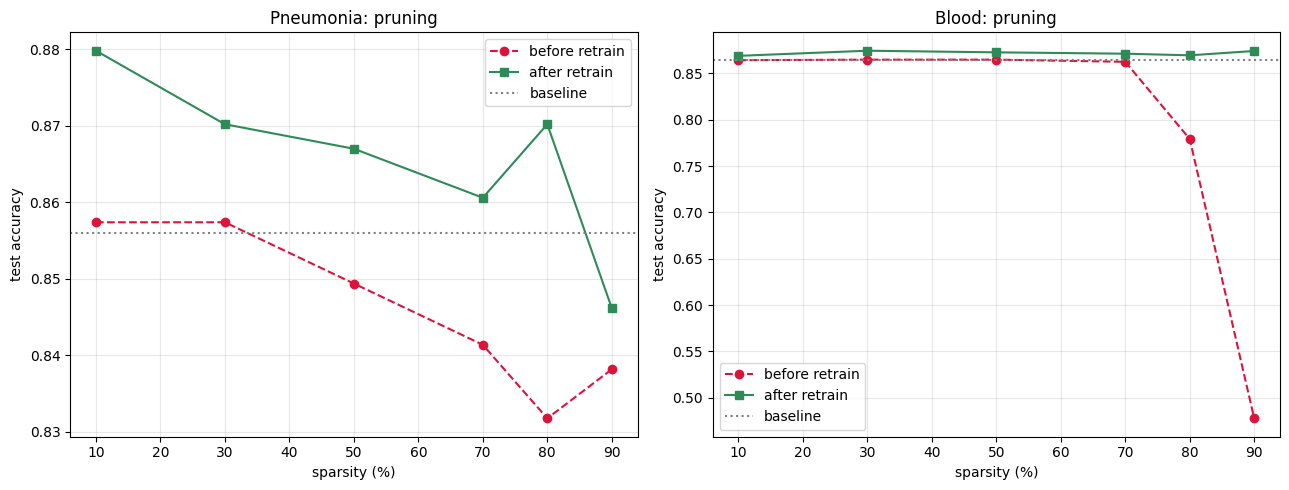

In [29]:
import matplotlib.pyplot as plt

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
for rows,ax,title,base in [(pr_p,ax1,"Pneumonia",0.856),(pr_b,ax2,"Blood",0.865)]:
    s=[r[0]*100 for r in rows]
    ax.plot(s,[r[1] for r in rows],'o--',label="before retrain",color="crimson")
    ax.plot(s,[r[2] for r in rows],'s-',label="after retrain",color="seagreen")
    ax.axhline(base,color="gray",ls=":",label="baseline")
    ax.set_title(f"{title}: pruning"); ax.set_xlabel("sparsity (%)"); ax.set_ylabel("test accuracy")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/fig_pruning.png",dpi=150,bbox_inches="tight"); plt.show()

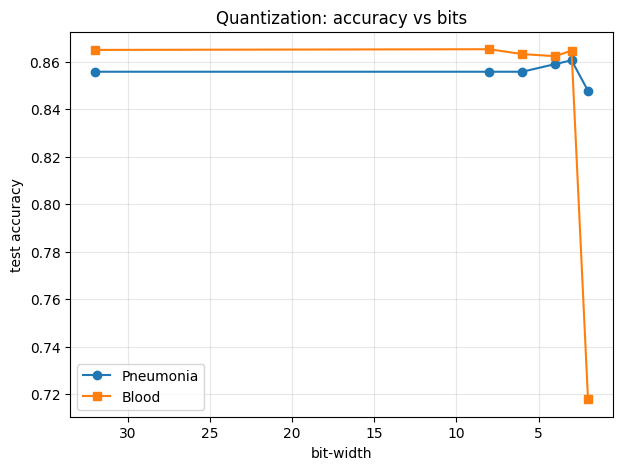

In [30]:
fig,ax=plt.subplots(figsize=(7,5))
ax.plot([r[0] for r in q_p],[r[1] for r in q_p],'o-',label="Pneumonia")
ax.plot([r[0] for r in q_b],[r[1] for r in q_b],'s-',label="Blood")
ax.set_xlabel("bit-width"); ax.set_ylabel("test accuracy"); ax.set_title("Quantization: accuracy vs bits")
ax.invert_xaxis(); ax.legend(); ax.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/fig_quant.png",dpi=150,bbox_inches="tight"); plt.show()

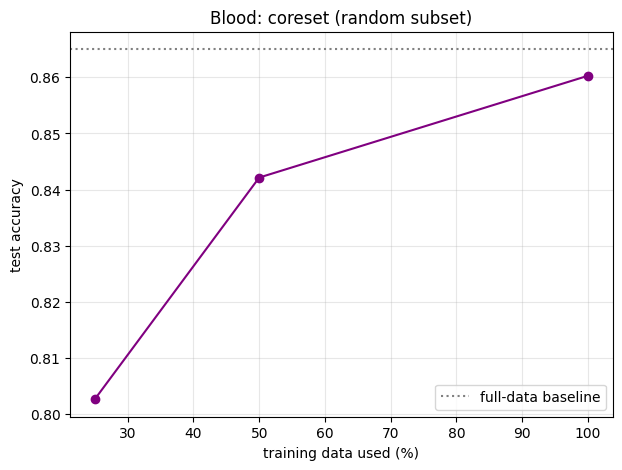

In [31]:
fig,ax=plt.subplots(figsize=(7,5))
ax.plot([r[0]*100 for r in co_b],[r[1] for r in co_b],'o-',color="purple")
ax.axhline(0.865,color="gray",ls=":",label="full-data baseline")
ax.set_xlabel("training data used (%)"); ax.set_ylabel("test accuracy"); ax.set_title("Blood: coreset (random subset)")
ax.legend(); ax.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/fig_coreset.png",dpi=150,bbox_inches="tight"); plt.show()

In [32]:
from sklearn.decomposition import PCA

def pca_study(Xtr,ytr,Xva,yva,Xte,yte,n_classes,name,dropout,lr,dims):
    print(f"\n{name} PCA + MLP:")
    print(f"{'dims':>6}{'acc':>8}{'f1':>8}")
    rows=[]
    for d in dims:
        pca=PCA(n_components=d,random_state=SEED).fit(Xtr)
        Xtr_p,Xva_p,Xte_p=pca.transform(Xtr),pca.transform(Xva),pca.transform(Xte)
        var=pca.explained_variance_ratio_.sum()
        m=train_mlp(Xtr_p.astype('float32'),ytr,Xva_p.astype('float32'),yva,d,n_classes,dropout=dropout,lr=lr)
        acc,f1=evaluate(m,Xte_p.astype('float32'),yte)
        rows.append((d,acc,f1,var)); print(f"{d:>6}{acc:>8.3f}{f1:>8.3f}  (var kept {var:.0%})")
    return rows

pca_p=pca_study(Xp_tr,yp_tr,Xp_va,yp_va,Xp_te,yp_te,2,"Pneumonia",0.5,3e-4,dims=[16,32,64,128])
pca_b=pca_study(Xb_tr,yb_tr,Xb_va,yb_va,Xb_te,yb_te,8,"Blood",0.3,1e-3,dims=[16,32,64,128])


Pneumonia PCA + MLP:
  dims     acc      f1
    16   0.835   0.808  (var kept 84%)
    32   0.851   0.826  (var kept 90%)
    64   0.841   0.812  (var kept 94%)
   128   0.883   0.867  (var kept 97%)

Blood PCA + MLP:
  dims     acc      f1
    16   0.773   0.752  (var kept 56%)
    32   0.830   0.810  (var kept 70%)
    64   0.833   0.815  (var kept 81%)
   128   0.852   0.834  (var kept 90%)


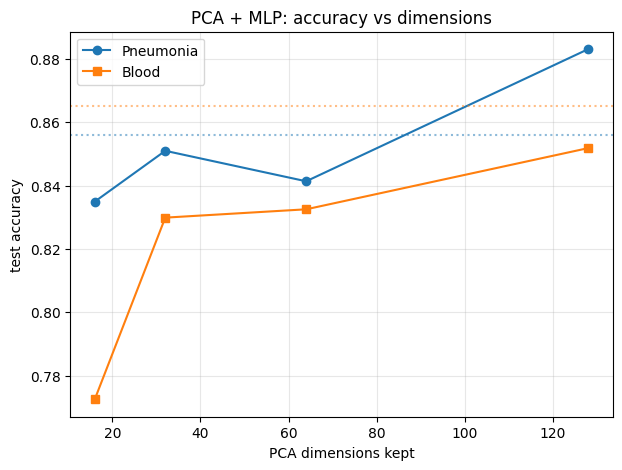

In [33]:
pd.DataFrame(pca_p,columns=["dims","acc","f1","var"]).to_csv(f"{SAVE_DIR}/pca_pneumonia.csv",index=False)
pd.DataFrame(pca_b,columns=["dims","acc","f1","var"]).to_csv(f"{SAVE_DIR}/pca_blood.csv",index=False)

fig,ax=plt.subplots(figsize=(7,5))
ax.plot([r[0] for r in pca_p],[r[1] for r in pca_p],'o-',label="Pneumonia")
ax.plot([r[0] for r in pca_b],[r[1] for r in pca_b],'s-',label="Blood")
ax.axhline(0.856,color='C0',ls=':',alpha=0.5); ax.axhline(0.865,color='C1',ls=':',alpha=0.5)
ax.set_xlabel("PCA dimensions kept"); ax.set_ylabel("test accuracy"); ax.set_title("PCA + MLP: accuracy vs dimensions")
ax.legend(); ax.grid(alpha=0.3)
plt.savefig(f"{SAVE_DIR}/fig_pca.png",dpi=150,bbox_inches="tight"); plt.show()